# Regresion logistica y metodos de regularizacion
Arle Almansa

In [1]:
# Importar librerias
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Parte 1:Regularizacion mediante un ejemplo polinomial

In [2]:
x1= np.arange (-1.3, 3.5, 0.125)

In [3]:
x2= x1*x1
x3= x1*x1*x1

In [4]:
# construccion de dataframe
W= np.concatenate((np.vstack(x1), np.vstack(x2), np.vstack(x3)), axis=1)

In [5]:
X= pd.DataFrame(W, columns=['x1','x2','x3'])

In [6]:
# Coheficientes de la funcion
w0= 195
w1= -85/3
w2= -165
w3= 160/3

In [7]:
# Introducir ruido  a la funcion
noise= 200 * (random.random()- 0.5)

In [8]:
X.head()

,x1,x2,x3
0,-1.300,1.690000,-2.197000
1,-1.175,1.380625,-1.622234
2,-1.050,1.102500,-1.157625
3,-0.925,0.855625,-0.791453
4,-0.800,0.640000,-0.512000


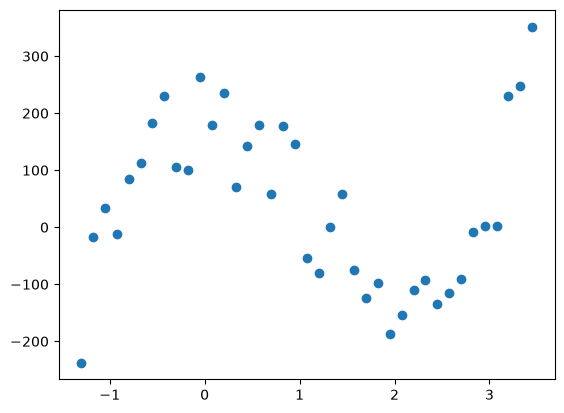

In [9]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)

plt.scatter(x1,yreal)
plt.show()

In [10]:
# Definamos 4 modelos: el de regresión lineal múltiple (RLM); de RLM con 
# regularización L1 (lasso); de RLM con regularización L2 (ridge) y
# RLM con regularización conjunta L1 y L2 (elastic-net):  

modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))  
modelos.append(('RIDGE', Ridge(alpha=30)))  
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

In [11]:
yhat0 = []   # predicciones del modelo RLM
yhat1 = []   # predicciones del RLM con regularización L1
yhat2 = []   # predicciones del RLM con regularización L2
yhat12 = []  # predicciones del RLM con regularización L1 y L2

In [12]:
for name, model in modelos:

  # entrenamos el modelo seleccionado y obtenemos sus predicciones:
  print("%s:" % name)
  mm = model.fit(X, np.ravel(yreal))
  yhat = mm.predict(X)
  print(mm.intercept_)   # por si deseas conocer w0.
  print(mm.coef_)       # despleguemos los pesos obtenidos
  if name=='LR':
    yhat0.append(yhat)
    print('\n')
  elif name=='LASSO':
    yhat1.append(yhat)
    print('\n')
  elif name=='RIDGE':
    yhat2.append(yhat)
    print('\n')
  else:
    yhat12.append(yhat)

LR:
199.9163838447491
[ -40.14979812 -179.70350006   58.72754395]


LASSO:
122.13069427863505
[  -0.         -102.25253563   31.42721669]


RIDGE:
93.97294849574072
[-27.51573296 -61.84734688  22.38804271]


EN:
110.48167999947972
[-32.10655264 -79.34645456  28.06434904]


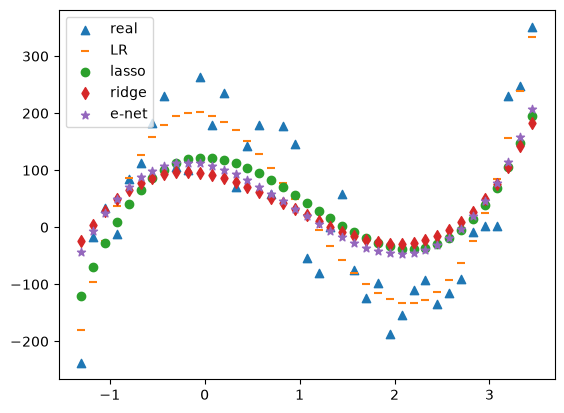

In [13]:
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  
plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  
plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  
plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  
plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')
plt.legend(loc=2)
plt.show()